# Rearrangement Trap Ramp Down Test

In [1]:
from pytweezer.experiment.motmaster_client import MotMasterClient
from pytweezer.drivers.imagemX2 import ImagEMX2Camera
from pytweezer.drivers.slm import SLM
from pytweezer.drivers.thorcam import ThorCamera
from pytweezer.experiment.experiment_parameter_manager import ExpParameterManager
import pytweezer.phasemask as pm
import pytweezer.analysis as an
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

ExpParams = ExpParameterManager()

In [2]:
exp : MotMasterClient = MotMasterClient()
motcam : ThorCamera = ThorCamera(id="motcam")
slm : SLM = SLM()
hamcam : ImagEMX2Camera = ImagEMX2Camera()

Rb MotMasterClient initialised.


Thorlabs TLCamera - motcam - initialised.
SLM 1 initialised: 1024x1024 @ 8-bit, serial 7752, 40.230 degC
SLM 1 loaded LUT "C:\Program Files\Meadowlark Optics\Blink Plus\LUT Files\slm40_at852.LUT"
ImagEM X2 camera initialised.


In [52]:
motcam.close()
slm.close()
hamcam.close()

Thorlabs TLCamera - motcam - closed.
SLM 1 closed.
ImagEM X2 camera closed.


In [41]:
exp : MotMasterClient = MotMasterClient()
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)
exp.set_motmaster_experiment("RbTweezerBasic2026_2")

motcam.set_trigger_source("bulb")

hamcam.set_trigger_source("ext")
hamcam.set_external_exposure_mode()
hamcam.enable_em_gain(True)
hamcam.enable_direct_em_gain(True)
hamcam.set_sensitivity(600)
hamcam.timeout = 60*5
X0, Y0, WIDTH, HEIGHT = 110, 220, 256, 256
hamcam.set_roi(X0, WIDTH, Y0, HEIGHT)

Rb MotMasterClient initialised.


## Generate Initial and Final Array Hologram

In [4]:
dx, dy = 8.0, 12.0
PM = pm.OptimisationBasedPhasemaskGeneratorGPU(
                 wavelength_um=0.852,
                 focal_length_mm=17.3,
                 slm_pitch_um=17,
                 slm_res=(1024,1024),
                 input_beam_waist_mm=16,
                 fresnel_f_mm=1072,
                 blaze_dx_dy_um=(40+dx, -8+dy),
                 zernike_coeff_dict={5:1.195, 6:0.725, 7:0.970, 8:0.478, 9:-1.091, 10:0.303, 11:0.021, 12:0.072, 13:0.049})

gauss2d = lambda x, y, A, x0, y0, sx, sy, offset: (A * np.exp(-(((x - x0) ** 2) / (2 * sx ** 2) + ((y - y0) ** 2) / (2 * sy ** 2)))) + offset
A, x0, y0, sx, sy, offset = [-2.14197604e+03, -1.11443850e+01 - dx, 2.09919600e+00 - dy, 2.95002910e+03, 2.64281503e+03, 2.14239505e+03]

--- System Configuration ---
SLM Plane Width: 17.41 mm
SLM Plane Height: 17.41 mm
Focal Plane Resolution x (pixel size): 0.8467 um
Focal Plane Resolution y (pixel size): 0.8467 um
Focal Plane Width: 867.04 um
Focal Plane Height: 867.04 um
Fresnel Lens Focal Length: 1072.00 mm
Blazed Grating Displacement (dx, dy): (48.0, 4.0) um


Initial array

In [5]:
W1 = np.ones((14,14))
spacing_um = 5.0

w_n, theta_n, x_n1, y_n1 = PM.generate_weighted_array(W1, spacing_um, init_phase_randomness=1.0, angle_deg=2.5)
w_n = gauss2d(x_n1, y_n1, A, x0, y0, sx, sy, offset)

terms1 = [w_n, theta_n, x_n1, y_n1]
pm_array1, terms1, _ = PM.superposition_optimization(terms1, max_iter=2000, damping=0.5, verbose=True)

--- Target Generation ---
Grid: 14x14
Spacing: 5.0 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 4.68e-06 | Uniformity: 42.84% | Min/Max ratio: 0.037
Iteration 010 | Mean-Squared Error: 3.99e-08 | Uniformity: 77.04% | Min/Max ratio: 0.399
Iteration 020 | Mean-Squared Error: 8.37e-09 | Uniformity: 77.31% | Min/Max ratio: 0.393
Iteration 030 | Mean-Squared Error: 3.80e-09 | Uniformity: 77.48% | Min/Max ratio: 0.408
Iteration 040 | Mean-Squared Error: 2.15e-09 | Uniformity: 77.57% | Min/Max ratio: 0.406
Iteration 050 | Mean-Squared Error: 1.76e-09 | Uniformity: 77.56% | Min/Max ratio: 0.412
Iteration 060 | Mean-Squared Error: 1.19e-09 | Uniformity: 77.40% | Min/Max ratio: 0.411
Iteration 070 | Mean-Squared Error: 7.58e-10 | Uniformity: 77.37% | Min/Max ratio: 0.409
Iteration 080 | Mean-Squared Error: 4.59e-10 | Uniformity: 77.35% | Min/Max ratio: 0.409
Iteration 090 | Mean-Squared Error: 3.07e-10 | Uniformity: 77.37% | Min/Max ratio: 0.407
Itera

Final array

In [6]:
W2 = np.ones((10,10))
spacing_um = 5.0

w_n, theta_n, x_n2, y_n2 = PM.generate_weighted_array(W2, spacing_um, init_phase_randomness=1.0, angle_deg=2.5)
w_n = gauss2d(x_n2, y_n2, A, x0, y0, sx, sy, offset)

terms2 = [w_n, theta_n, x_n2, y_n2]
pm_array2, terms2, _ = PM.superposition_optimization(terms2, max_iter=2000, damping=0.5, verbose=True)

--- Target Generation ---
Grid: 10x10
Spacing: 5.0 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 1.80e-05 | Uniformity: 49.85% | Min/Max ratio: 0.036
Iteration 010 | Mean-Squared Error: 1.60e-07 | Uniformity: 82.90% | Min/Max ratio: 0.460
Iteration 020 | Mean-Squared Error: 9.01e-09 | Uniformity: 83.71% | Min/Max ratio: 0.531
Iteration 030 | Mean-Squared Error: 1.00e-09 | Uniformity: 83.54% | Min/Max ratio: 0.529
Iteration 040 | Mean-Squared Error: 1.41e-09 | Uniformity: 83.53% | Min/Max ratio: 0.529
Iteration 050 | Mean-Squared Error: 1.17e-09 | Uniformity: 83.55% | Min/Max ratio: 0.530
Iteration 060 | Mean-Squared Error: 1.05e-09 | Uniformity: 83.58% | Min/Max ratio: 0.530
Iteration 070 | Mean-Squared Error: 1.57e-09 | Uniformity: 83.65% | Min/Max ratio: 0.531
Iteration 080 | Mean-Squared Error: 1.35e-09 | Uniformity: 83.65% | Min/Max ratio: 0.529
Iteration 090 | Mean-Squared Error: 1.25e-09 | Uniformity: 83.60% | Min/Max ratio: 0.529
Itera

Load initial array onto the SLM

In [42]:
pm_composite = PM.superimpose([pm_array1, PM.fresnel, PM.blaze, PM.zernike])
pm_composite_uint8 = PM.transform_phase_8bit(pm_composite).get()
slm.update_mask(pm_composite_uint8)

## Baseline - Load and Image Initial Array

Parameter 'conversion_factor' set to 0.009508957628343926.
Parameter 'conversion_offset' set to 1917.159423828125.
Parameters saved.


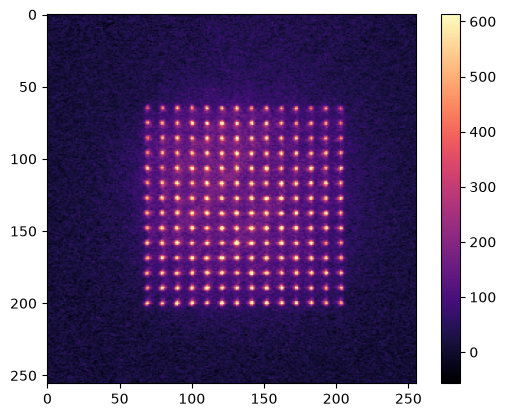

In [43]:
# Experiment and camera setup
n_iterations = 100
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)
hamcam.start_acquisition()
exp.start_motmaster_experiment({
    "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
    "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
    "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"),
    "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
    "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"),
    "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
    "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"),
    "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
    "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
    "tMolassesShimXccValue": ExpParams.get_parameter("tMolassesShimXccValue"), "tMolassesShimYccValue": ExpParams.get_parameter("tMolassesShimYccValue"), "tMolassesShimZccValue": ExpParams.get_parameter("tMolassesShimZccValue"),
    "tTweezerSetVVA0": 0.0, "tTweezerSetVVA1": 0.0,
    "BackgroundDrop": 1})

imgs = hamcam.acquire_n_frames(n_iterations * 2)
imgs1, imgs2 = imgs[::2], imgs[1::2]
img_average = an.tweezer_show_bg_subtracted(imgs1, imgs2, cmap='magma', show=True, vmaxfactor=0.6, show_grid=True)

ExpParams.set_parameter("conversion_factor", hamcam.dcam.get_attribute_value("CONVERSION FACTOR COEFF"))
ExpParams.set_parameter("conversion_offset", hamcam.dcam.get_attribute_value("CONVERSION FACTOR OFFSET"))
ExpParams.save_parameters()

Looking for trap sites...
196 Atoms Detected.
Parameter 'x_centre' set to 135.8265306122449.
Parameter 'y_centre' set to 131.84183673469389.
Parameters saved.


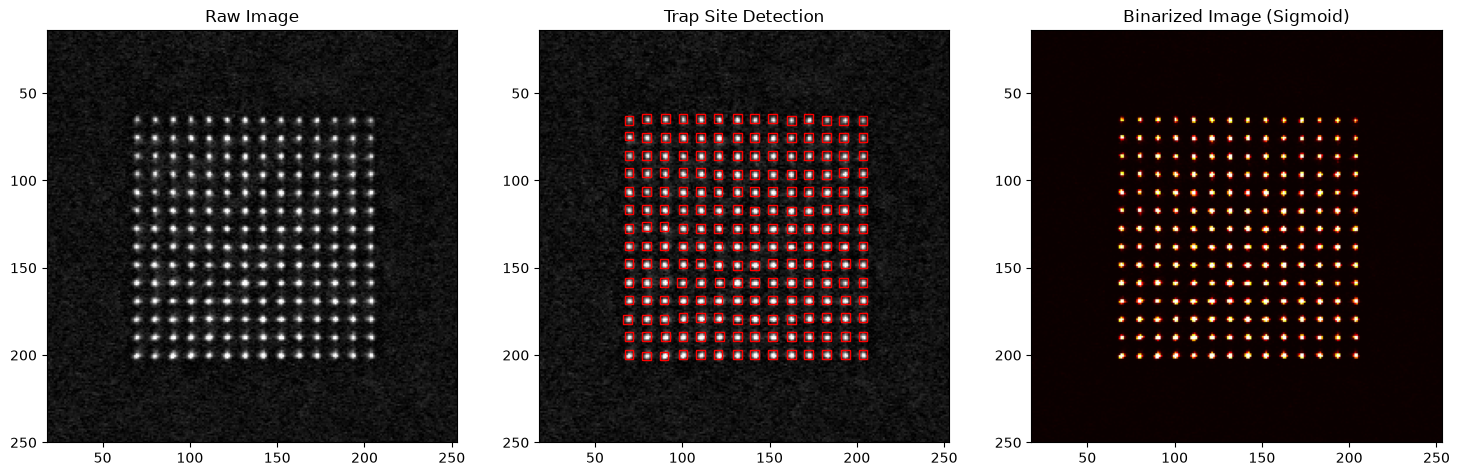

Trap (0) Loading Probability : 50.00 %
Trap (1) Loading Probability : 61.00 %
Trap (2) Loading Probability : 49.00 %
Trap (3) Loading Probability : 55.00 %
Trap (4) Loading Probability : 53.00 %
Trap (5) Loading Probability : 54.00 %
Trap (6) Loading Probability : 51.00 %
Trap (7) Loading Probability : 51.00 %
Trap (8) Loading Probability : 50.00 %
Trap (9) Loading Probability : 58.00 %
Trap (10) Loading Probability : 62.00 %
Trap (11) Loading Probability : 46.00 %
Trap (12) Loading Probability : 48.00 %
Trap (13) Loading Probability : 48.00 %
Trap (14) Loading Probability : 56.00 %
Trap (15) Loading Probability : 58.00 %
Trap (16) Loading Probability : 54.00 %
Trap (17) Loading Probability : 59.00 %
Trap (18) Loading Probability : 66.00 %
Trap (19) Loading Probability : 54.00 %
Trap (20) Loading Probability : 58.00 %
Trap (21) Loading Probability : 60.00 %
Trap (22) Loading Probability : 62.00 %
Trap (23) Loading Probability : 48.00 %
Trap (24) Loading Probability : 51.00 %
Trap (25) 

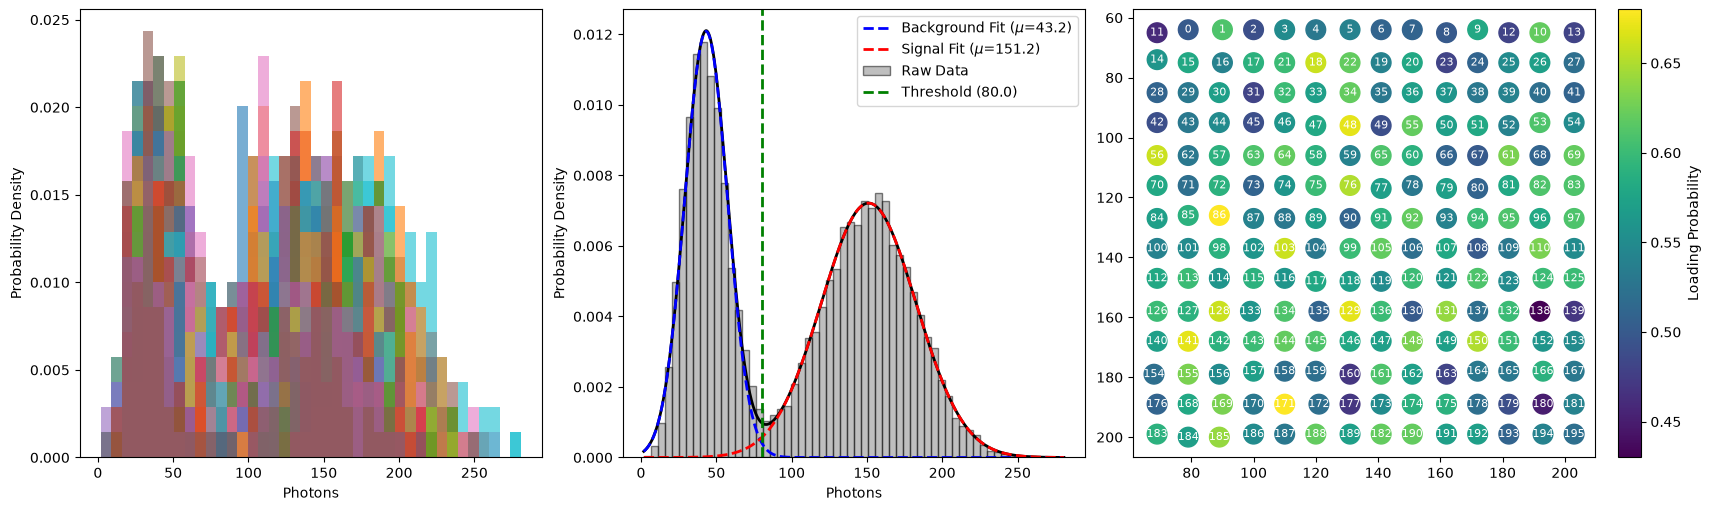

In [ ]:
feature_size, window = 10, 5
img_average_filtered = an.morphological_tophat_high_pass(img_average, feature_size=feature_size)
grid_positions, detection_threshold = an.detect_trap_sites(img_average_filtered, 14*14, detection_step=100)
an.set_array_centre(grid_positions)
grid_positions = an.index_grid_positions(grid_positions, x_n1, y_n1)
an.visualize_results(img_average_filtered, grid_positions, margin=50, window_size=window, threshold=detection_threshold*1.5, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.6)
imgs_n_filtered = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
photons, loading_probabilities, threshold_1, fidelity = an.get_array_loading_statistics(imgs_n_filtered, grid_positions, threshold=100, window_size=5, binning=60, 
                                                                                        show_histogram=True, threshold_detection=True, verbose=True, show_site_labels=True)

Trap (0) Loading Probability : 54.00 %
Trap (1) Loading Probability : 63.00 %
Trap (2) Loading Probability : 50.00 %
Trap (3) Loading Probability : 56.00 %
Trap (4) Loading Probability : 55.00 %
Trap (5) Loading Probability : 55.00 %
Trap (6) Loading Probability : 52.00 %
Trap (7) Loading Probability : 51.00 %
Trap (8) Loading Probability : 51.00 %
Trap (9) Loading Probability : 58.00 %
Trap (10) Loading Probability : 66.00 %
Trap (11) Loading Probability : 52.00 %
Trap (12) Loading Probability : 53.00 %
Trap (13) Loading Probability : 54.00 %
Trap (14) Loading Probability : 61.00 %
Trap (15) Loading Probability : 58.00 %
Trap (16) Loading Probability : 55.00 %
Trap (17) Loading Probability : 58.00 %
Trap (18) Loading Probability : 66.00 %
Trap (19) Loading Probability : 53.00 %
Trap (20) Loading Probability : 61.00 %
Trap (21) Loading Probability : 60.00 %
Trap (22) Loading Probability : 62.00 %
Trap (23) Loading Probability : 49.00 %
Trap (24) Loading Probability : 54.00 %
Trap (25) 

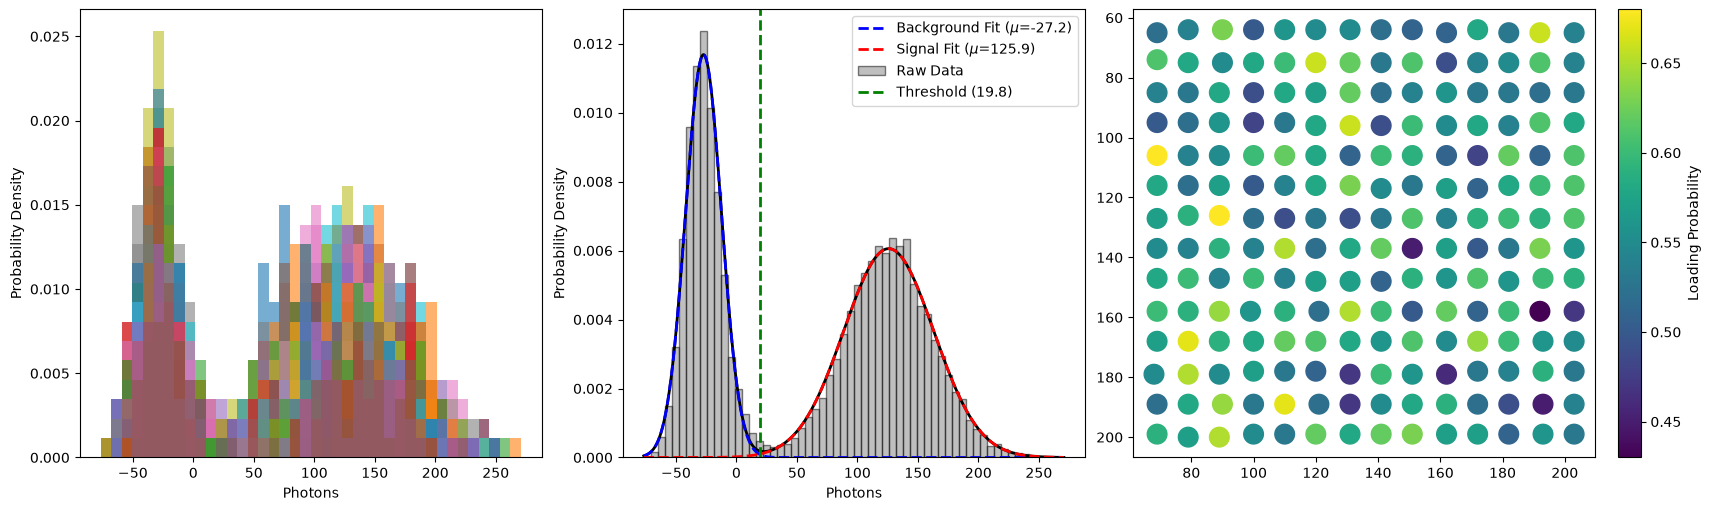

In [45]:
# Analyse images (fliplr) with indexed grid positions - PSF
psf_window = 9

# Templates come from the raw frames - the matched filter needs no top-hat.
scorer = an.SiteScorer.from_images(imgs1, grid_positions, window_size=psf_window)
photons, loading_probabilities, threshold_1, fidelity = an.get_array_loading_statistics(
    imgs1, grid_positions, scorer=scorer, threshold_detection=True, binning=60)

scorer.threshold = threshold_1 * 1.0
print(f"PSF threshold {scorer.threshold:.2f} photons, detection fidelity {fidelity*100:.3f} %")

In [101]:
# Experiment and camera setup
n_iterations = 100
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)
hamcam.start_acquisition()
exp.start_motmaster_experiment({
    "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
    "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
    "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"),
    "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
    "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"),
    "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
    "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"),
    "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
    "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
    "tMolassesShimXccValue": ExpParams.get_parameter("tMolassesShimXccValue"), "tMolassesShimYccValue": ExpParams.get_parameter("tMolassesShimYccValue"), "tMolassesShimZccValue": ExpParams.get_parameter("tMolassesShimZccValue"),
    "tTweezerSetVVA0": 9.0, "tTweezerSetVVA1": 9.0, "tDelay2": 5000,
    "BackgroundDrop": 0})

imgs = hamcam.acquire_n_frames(n_iterations * 2)
imgs1, imgs2 = imgs[::2], imgs[1::2]

In [102]:
def extract_survival_probability(imgs1, imgs2, grid_positions, threshold='auto', window_size=5):
    if threshold == 'auto':
        pr_1, eta_1, thresh_1, fidelity_1 = an.get_array_loading_statistics(imgs1, grid_positions, scorer=scorer, threshold_detection=True, binning=60, show_histogram=False)
        pr_2, eta_2, thresh_2, fidelity_2 = an.get_array_loading_statistics(imgs2, grid_positions, scorer=scorer, threshold_detection=True, binning=60, show_histogram=False)
    else:
        pr_1, eta_1, thresh_1, fidelity_1 = an.get_array_loading_statistics(imgs1, grid_positions, scorer=scorer, threshold_detection=True, binning=60, show_histogram=False)
        pr_2, eta_2, thresh_2, fidelity_2 = an.get_array_loading_statistics(imgs2, grid_positions, scorer=scorer, threshold_detection=True, binning=60, show_histogram=False)
    survival_fractions = []
    for i in range(pr_1.shape[0]):

        pr_mat_1 = pr_1[i]
        pr_mat_2 = pr_2[i]

        pr_mat_1_binary = (pr_mat_1 > thresh_1).astype(int)
        pr_mat_2_binary = (pr_mat_2 > thresh_2).astype(int)
        survival_matrix = pr_mat_1_binary * pr_mat_2_binary

        init_occupation = pr_mat_1_binary.sum()
        final_occupation = pr_mat_2_binary.sum()
        survival_count = survival_matrix.sum()
        survival_fraction = survival_count / init_occupation if init_occupation > 0 else 0
        survival_fractions.append(survival_fraction)

    survival_probability = np.mean(survival_fractions)
    return survival_probability

Detected Loading Threshold: 7.33 photons
Std dev of Loading Probabilities: 8.71 %
Mean Loading Probability: 57.33 %
Detection Fidelity: 99.82 %
Mean Background Photon Count: -25.68 photons, Variance: 108.91 photons^2
Mean Signal Photon Count: 93.94 photons, Variance: 957.34 photons^2
Detected Loading Threshold: 4.56 photons
Std dev of Loading Probabilities: 8.93 %
Mean Loading Probability: 55.90 %
Detection Fidelity: 99.94 %
Mean Background Photon Count: -25.68 photons, Variance: 75.82 photons^2
Mean Signal Photon Count: 93.91 photons, Variance: 825.36 photons^2
Trap (0) Loading Probability : 45.00 %
Trap (1) Loading Probability : 58.00 %
Trap (2) Loading Probability : 48.00 %
Trap (3) Loading Probability : 54.00 %
Trap (4) Loading Probability : 52.00 %
Trap (5) Loading Probability : 63.00 %
Trap (6) Loading Probability : 56.00 %
Trap (7) Loading Probability : 54.00 %
Trap (8) Loading Probability : 59.00 %
Trap (9) Loading Probability : 56.00 %
Trap (10) Loading Probability : 52.00 %
T

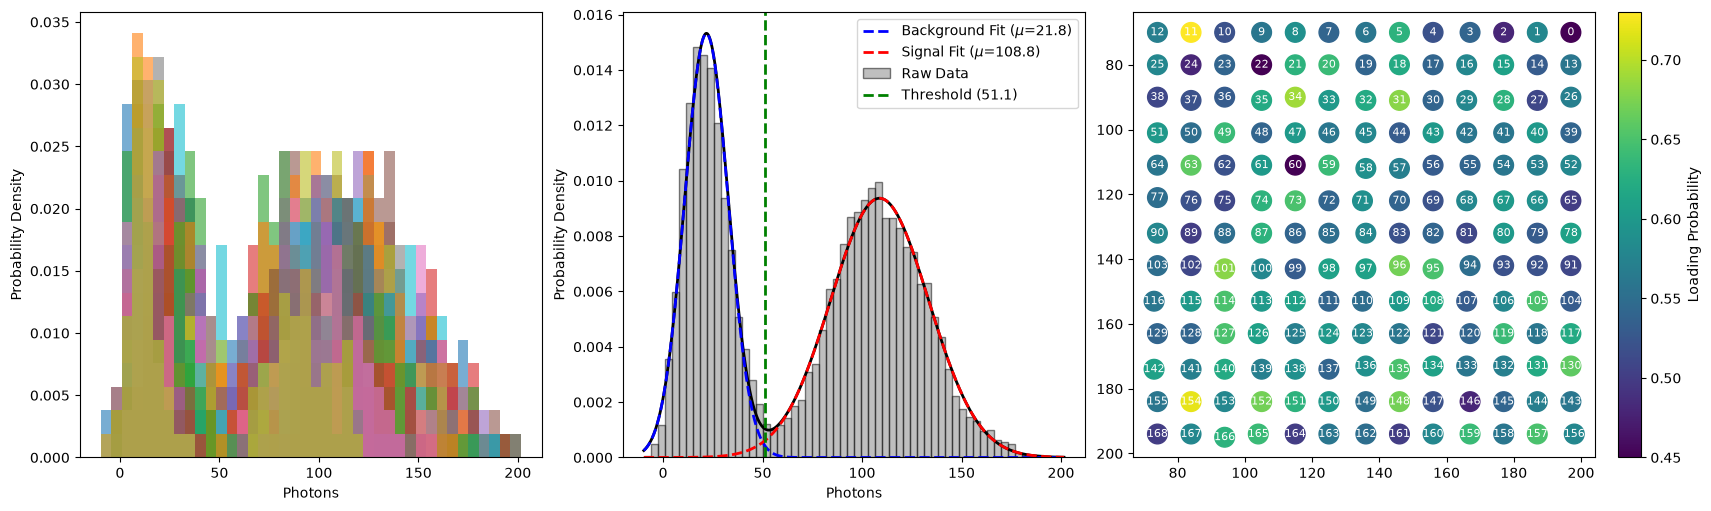

In [103]:
imgs_filtered_1 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
imgs_filtered_2 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs2]
baseline_survival_probability = extract_survival_probability(imgs_filtered_1, imgs_filtered_2, grid_positions, window_size=window)
out_ = an.get_array_loading_statistics(imgs_filtered_1, grid_positions, threshold_detection=True, window_size=window, binning=60, show_site_labels=True)
print(f"Baseline survival probability: {baseline_survival_probability:.4f}")

### MOT Shim Coil Optimisation

In [152]:
from skopt.space import Real, Integer
from skopt.utils import use_named_args
from skopt import Optimizer

In [50]:
# --- 1. Define the Experimental Search Space ---
dimensions = [  
    Real(name='tMOTShimXccValue', low=0.0, high=0.5),
    Real(name='tMOTShimYccValue', low=-5.0, high=0.0),
    Real(name='tMOTShimZccValue', low=-1.0, high=0.0)
]

# Experiment and camera setup
n_iterations = 20
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)

@use_named_args(dimensions=dimensions)
def tweezer_exp_objective(tMOTShimXccValue, tMOTShimYccValue, tMOTShimZccValue):
    hamcam.start_acquisition()
    exp.start_motmaster_experiment({
            "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
            "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
            "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"), 
            "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
            "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"), 
            "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
            "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"), 
            "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
            "tMOTShimXccValue": tMOTShimXccValue, "tMOTShimYccValue": tMOTShimYccValue, "tMOTShimZccValue": tMOTShimZccValue,
            "tMolassesShimXccValue": ExpParams.get_parameter("tMolassesShimXccValue"), "tMolassesShimYccValue": ExpParams.get_parameter("tMolassesShimYccValue"), "tMolassesShimZccValue": ExpParams.get_parameter("tMolassesShimZccValue"),
            "tMOTLoadingDuration": 30000, "PatternLength": 50000})

    imgs = hamcam.acquire_n_frames(n_iterations * 2)
    imgs1, imgs2 = imgs[::2], imgs[1::2]
    imgs_filtered_1 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]

    _, loading_probabilities, _, _ = an.get_array_loading_statistics(imgs_filtered_1, grid_positions, threshold_detection=False, threshold=threshold_1, binning=60, show_histogram=False, verbose=False)    
    mean_loading_probability = np.mean(loading_probabilities)
    measured_loss = 1.0 - mean_loading_probability

    print(f"Parameters: tMOTShimXccValue = {tMOTShimXccValue:.2f}, tMOTShimYccValue = {tMOTShimYccValue:.2f}, tMOTShimZccValue = {tMOTShimZccValue:.2f}  |  Mean Loading Probability = {mean_loading_probability:.4f}")
    return measured_loss

In [51]:
print("Starting Bayesian Optimization with dynamic exploration...")

n_calls = 50
n_initial_points = 5
xi_start = 0.100
xi_end = 0.001

opt = Optimizer(
    dimensions=dimensions,
    n_initial_points=n_initial_points,
    acq_func='EI',
    random_state=50
)

# Custom optimization loop
for i in range(n_calls):
    current_xi = xi_start - (xi_start - xi_end) * (i / (n_calls - 1))
    opt.acq_func_kwargs = {'xi': current_xi}
    suggested_params = opt.ask()
    loss = tweezer_exp_objective(suggested_params)
    result = opt.tell(suggested_params, loss)
    print(f"Iteration {i+1}/{n_calls} (xi = {current_xi:.4f})")
    print(f"  Current score: {(1-loss):.4f}")
    print(f"  Best score: {(1-result.fun):.4f}\n")

# --- 4. Analyze the Results ---
print("\n" + "="*40)
print("Optimization Complete!")
print("="*40)

high_score = 1 - result.fun
best_params = result.x

print(f"Best Parameters Found:")
for dim, value in zip(dimensions, best_params):
    print(f"  {dim.name}: {value:.4f}")

Starting Bayesian Optimization with dynamic exploration...
Parameters: tMOTShimXccValue = 0.06, tMOTShimYccValue = -4.63, tMOTShimZccValue = -0.39  |  Mean Loading Probability = 0.0615
Iteration 1/50 (xi = 0.1000)
  Current score: 0.0615
  Best score: 0.0615

Parameters: tMOTShimXccValue = 0.01, tMOTShimYccValue = -4.24, tMOTShimZccValue = -0.05  |  Mean Loading Probability = 0.3177
Iteration 2/50 (xi = 0.0980)
  Current score: 0.3177
  Best score: 0.3177

Parameters: tMOTShimXccValue = 0.40, tMOTShimYccValue = -3.78, tMOTShimZccValue = -0.67  |  Mean Loading Probability = 0.0094
Iteration 3/50 (xi = 0.0960)
  Current score: 0.0094
  Best score: 0.3177

Parameters: tMOTShimXccValue = 0.22, tMOTShimYccValue = -4.33, tMOTShimZccValue = -0.41  |  Mean Loading Probability = 0.0618
Iteration 4/50 (xi = 0.0939)
  Current score: 0.0618
  Best score: 0.3177

Parameters: tMOTShimXccValue = 0.49, tMOTShimYccValue = -4.56, tMOTShimZccValue = -0.71  |  Mean Loading Probability = 0.0056
Iteration 5

In [52]:
ExpParams.set_parameter("tMOTShimXccValue", best_params[0])
ExpParams.set_parameter("tMOTShimYccValue", best_params[1])
ExpParams.set_parameter("tMOTShimZccValue", best_params[2])
ExpParams.save_parameters()

Parameter 'tMOTShimXccValue' set to 0.4991451750157772.
Parameter 'tMOTShimYccValue' set to -1.8648591545365227.
Parameter 'tMOTShimZccValue' set to -0.08719931424260197.
Parameters saved.


### Molasses Shim Coil Optimisation

In [167]:
# --- 1. Define the Experimental Search Space ---
dimensions = [  
    Real(name='tMolassesShimXccValue', low=5.0, high=10.0), 
    Real(name='tMolassesShimYccValue', low=0.0, high=5.0), 
    Real(name='tMolassesShimZccValue', low=0.0, high=1.0)
]

# Experiment and camera setup
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)

@use_named_args(dimensions=dimensions)
def tweezer_exp_objective(tMolassesShimXccValue, tMolassesShimYccValue, tMolassesShimZccValue):
    # Check loading probability
    n_iterations = 20
    exp.set_motmaster_experiment("RbTweezerBasic2026_2")
    exp.set_iterations(n_iterations)
    hamcam.setup_acquisition("snap", n_iterations * 2)
    hamcam.start_acquisition()
    exp.start_motmaster_experiment({
        "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
        "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
        "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"),
        "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
        "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"),
        "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
        "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"),
        "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
        "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
        "tMolassesShimXccValue": tMolassesShimXccValue, "tMolassesShimYccValue": tMolassesShimYccValue, "tMolassesShimZccValue": tMolassesShimZccValue, 
        "BackgroundDrop": 1, "tDropDuration": int(4)})
    imgs = hamcam.acquire_n_frames(n_iterations * 2)
    imgs1, imgs2 = imgs[::2], imgs[1::2]
    imgs_filtered_1 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
    imgs_filtered_2 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs2]
    _, loading_probabilities, threshold, _ = an.get_array_loading_statistics(imgs_filtered_1, grid_positions, threshold_detection=False, threshold=threshold_1, binning=60, show_histogram=False, verbose=False)

    mean_loading_probability = loading_probabilities.mean()

    if mean_loading_probability < 0.5:
        measured_loss = 1 - mean_loading_probability
        survival_probability = np.nan
    else:
        survival_probability = an.extract_survival_probability(imgs_filtered_1, imgs_filtered_2, grid_positions, threshold=threshold, window_size=window)
        measured_loss = 0.4 - survival_probability

    print(f"tMolassesShimXccValue = {tMolassesShimXccValue:.2f}, tMolassesShimYccValue = {tMolassesShimYccValue:.2f}, tMolassesShimZccValue = {tMolassesShimZccValue:.2f}  |  Loading Probability = {mean_loading_probability:.4f}  |  40 us Survival Probability = {survival_probability:.4f}")
    
    return measured_loss

In [168]:
print("Starting Bayesian Optimization with dynamic exploration...")

n_calls = 50
n_initial_points = 10
xi_start = 0.100
xi_end = 0.001

opt = Optimizer(
    dimensions=dimensions,
    n_initial_points=n_initial_points,
    acq_func='EI',
    random_state=50
)

# Custom optimization loop
for i in range(n_calls):
    current_xi = xi_start - (xi_start - xi_end) * (i / (n_calls - 1))
    opt.acq_func_kwargs = {'xi': current_xi}
    suggested_params = opt.ask()
    loss = tweezer_exp_objective(suggested_params)
    result = opt.tell(suggested_params, loss)
    print(f"Iteration {i+1}/{n_calls} (xi = {current_xi:.4f})")
    print(f"  Current score: {(loss):.4f}")
    print(f"  Best score: {(result.fun):.4f}\n")

# --- 4. Analyze the Results ---
print("\n" + "="*40)
print("Optimization Complete!")
print("="*40)

high_score = 1 - result.fun
best_params = result.x

print(f"Best Parameters Found:")
for dim, value in zip(dimensions, best_params):
    print(f"  {dim.name}: {value:.4f}")

Starting Bayesian Optimization with dynamic exploration...


tMolassesShimXccValue = 5.65, tMolassesShimYccValue = 0.37, tMolassesShimZccValue = 0.61  |  Loading Probability = 0.0007  |  40 us Survival Probability = nan
Iteration 1/50 (xi = 0.1000)
  Current score: 0.9993
  Best score: 0.9993



C:\Users\tweez\ColdMatter\pytweezer\pytweezer\analysis.py:741: RuntimeWarning: Mean of empty slice
  mu_sig = tot_photon_array[tot_photon_array >= threshold].mean()
c:\Users\tweez\AppData\Local\pypoetry\Cache\virtualenvs\pytweezer-E_bIt_dZ-py3.11\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\tweez\ColdMatter\pytweezer\pytweezer\analysis.py:743: RuntimeWarning: Degrees of freedom <= 0 for slice
  var_sig = tot_photon_array[tot_photon_array >= threshold].var()
c:\Users\tweez\AppData\Local\pypoetry\Cache\virtualenvs\pytweezer-E_bIt_dZ-py3.11\Lib\site-packages\numpy\_core\_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\tweez\AppData\Local\pypoetry\Cache\virtualenvs\pytweezer-E_bIt_dZ-py3.11\Lib\site-packages\numpy\_core\_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = 

tMolassesShimXccValue = 5.11, tMolassesShimYccValue = 0.76, tMolassesShimZccValue = 0.95  |  Loading Probability = 0.0000  |  40 us Survival Probability = nan
Iteration 2/50 (xi = 0.0980)
  Current score: 1.0000
  Best score: 0.9993

tMolassesShimXccValue = 9.02, tMolassesShimYccValue = 1.22, tMolassesShimZccValue = 0.33  |  Loading Probability = 0.2762  |  40 us Survival Probability = nan
Iteration 3/50 (xi = 0.0960)
  Current score: 0.7238
  Best score: 0.7238

tMolassesShimXccValue = 7.20, tMolassesShimYccValue = 0.67, tMolassesShimZccValue = 0.59  |  Loading Probability = 0.0011  |  40 us Survival Probability = nan
Iteration 4/50 (xi = 0.0939)
  Current score: 0.9989
  Best score: 0.7238

tMolassesShimXccValue = 9.89, tMolassesShimYccValue = 0.44, tMolassesShimZccValue = 0.29  |  Loading Probability = 0.1709  |  40 us Survival Probability = nan
Iteration 5/50 (xi = 0.0919)
  Current score: 0.8291
  Best score: 0.7238

tMolassesShimXccValue = 6.20, tMolassesShimYccValue = 2.58, tMol

C:\Users\tweez\ColdMatter\pytweezer\pytweezer\analysis.py:741: RuntimeWarning: Mean of empty slice
  mu_sig = tot_photon_array[tot_photon_array >= threshold].mean()
c:\Users\tweez\AppData\Local\pypoetry\Cache\virtualenvs\pytweezer-E_bIt_dZ-py3.11\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\tweez\ColdMatter\pytweezer\pytweezer\analysis.py:743: RuntimeWarning: Degrees of freedom <= 0 for slice
  var_sig = tot_photon_array[tot_photon_array >= threshold].var()
c:\Users\tweez\AppData\Local\pypoetry\Cache\virtualenvs\pytweezer-E_bIt_dZ-py3.11\Lib\site-packages\numpy\_core\_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\tweez\AppData\Local\pypoetry\Cache\virtualenvs\pytweezer-E_bIt_dZ-py3.11\Lib\site-packages\numpy\_core\_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = 

tMolassesShimXccValue = 10.00, tMolassesShimYccValue = 0.00, tMolassesShimZccValue = 1.00  |  Loading Probability = 0.0000  |  40 us Survival Probability = nan
Iteration 26/50 (xi = 0.0495)
  Current score: 1.0000
  Best score: 0.1085



C:\Users\tweez\ColdMatter\pytweezer\pytweezer\analysis.py:741: RuntimeWarning: Mean of empty slice
  mu_sig = tot_photon_array[tot_photon_array >= threshold].mean()
c:\Users\tweez\AppData\Local\pypoetry\Cache\virtualenvs\pytweezer-E_bIt_dZ-py3.11\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\tweez\ColdMatter\pytweezer\pytweezer\analysis.py:743: RuntimeWarning: Degrees of freedom <= 0 for slice
  var_sig = tot_photon_array[tot_photon_array >= threshold].var()
c:\Users\tweez\AppData\Local\pypoetry\Cache\virtualenvs\pytweezer-E_bIt_dZ-py3.11\Lib\site-packages\numpy\_core\_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\tweez\AppData\Local\pypoetry\Cache\virtualenvs\pytweezer-E_bIt_dZ-py3.11\Lib\site-packages\numpy\_core\_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = 

tMolassesShimXccValue = 10.00, tMolassesShimYccValue = 5.00, tMolassesShimZccValue = 1.00  |  Loading Probability = 0.0000  |  40 us Survival Probability = nan
Iteration 27/50 (xi = 0.0475)
  Current score: 1.0000
  Best score: 0.1085

tMolassesShimXccValue = 6.07, tMolassesShimYccValue = 2.84, tMolassesShimZccValue = 0.18  |  Loading Probability = 0.5644  |  40 us Survival Probability = 0.2412
Iteration 28/50 (xi = 0.0454)
  Current score: 0.1588
  Best score: 0.1085



KeyboardInterrupt: 

In [46]:
for dim, value in zip(dimensions, best_params):
    print(f"  {dim.name}: {value:.4f}")
    ExpParams.set_parameter(dim.name, value)
ExpParams.save_parameters()

  tMolassesShimXccValue: 5.6100
Parameter 'tMolassesShimXccValue' set to 5.609956063783662.
  tMolassesShimYccValue: 4.4659
Parameter 'tMolassesShimYccValue' set to 4.465918604815521.
  tMolassesShimZccValue: 0.1365
Parameter 'tMolassesShimZccValue' set to 0.13646836204370819.
Parameters saved.


### Imaging VCO Scan

In [146]:
# Experiment and camera setup
n_iterations = 20
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)

vco_list = np.linspace(1.0, 3.0, 30)
surv_list, loading_list, fidelity_list = [], [], []

for vco in vco_list:
    ExpParams.set_parameter("tImgCoolVCO", vco)
    hamcam.start_acquisition()
    exp.start_motmaster_experiment({
        "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
        "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
        "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"), 
        "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
        "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"), 
        "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
        "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"), 
        "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
        "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
        "tMolassesShimXccValue": ExpParams.get_parameter("tMolassesShimXccValue"), "tMolassesShimYccValue": ExpParams.get_parameter("tMolassesShimYccValue"), "tMolassesShimZccValue": ExpParams.get_parameter("tMolassesShimZccValue"),
        "BackgroundDrop": 0})

    imgs = hamcam.acquire_n_frames(n_iterations * 2)
    imgs1, imgs2 = imgs[::2], imgs[1::2]
    imgs_filtered_1 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
    imgs_filtered_2 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs2]
    photon_rates, loading_probabilities, threshold, fidelity = an.get_array_loading_statistics(imgs_filtered_1, grid_positions, threshold_detection=True, window_size=window, binning=60, verbose=False, show_histogram=False)
    survival_probability = an.extract_survival_probability(imgs_filtered_1, imgs_filtered_2, grid_positions, window_size=window)
    mean_loading_probability = np.mean(loading_probabilities)

    surv_list.append(survival_probability)
    loading_list.append(mean_loading_probability)
    fidelity_list.append(fidelity)

    print(f"Cooling VCO: {vco:.3f} V, Mean Loading Probability: {mean_loading_probability*100:.4f} %, Survival Probability: {survival_probability*100:.4f} %, Detection Fidelity: {fidelity*100:.4f} %")

Parameter 'tImgCoolVCO' set to 1.0.
Cooling VCO: 1.000 V, Mean Loading Probability: 56.8667 %, Survival Probability: 96.2144 %, Detection Fidelity: 98.9785 %
Parameter 'tImgCoolVCO' set to 1.0689655172413792.
Cooling VCO: 1.069 V, Mean Loading Probability: 55.3778 %, Survival Probability: 96.6843 %, Detection Fidelity: 99.2334 %
Parameter 'tImgCoolVCO' set to 1.1379310344827587.
Cooling VCO: 1.138 V, Mean Loading Probability: 56.6444 %, Survival Probability: 96.1448 %, Detection Fidelity: 99.2705 %
Parameter 'tImgCoolVCO' set to 1.206896551724138.
Cooling VCO: 1.207 V, Mean Loading Probability: 55.4444 %, Survival Probability: 97.2029 %, Detection Fidelity: 99.5012 %
Parameter 'tImgCoolVCO' set to 1.2758620689655173.
Cooling VCO: 1.276 V, Mean Loading Probability: 55.1333 %, Survival Probability: 97.3835 %, Detection Fidelity: 99.5550 %
Parameter 'tImgCoolVCO' set to 1.3448275862068966.
Cooling VCO: 1.345 V, Mean Loading Probability: 54.9556 %, Survival Probability: 97.4331 %, Detectio

Optimal Cooling VCO: 1.483 V, Survival Probability: 97.7119 %, Loading Probability: 53.8222 %, Detection Fidelity: 99.6644 %


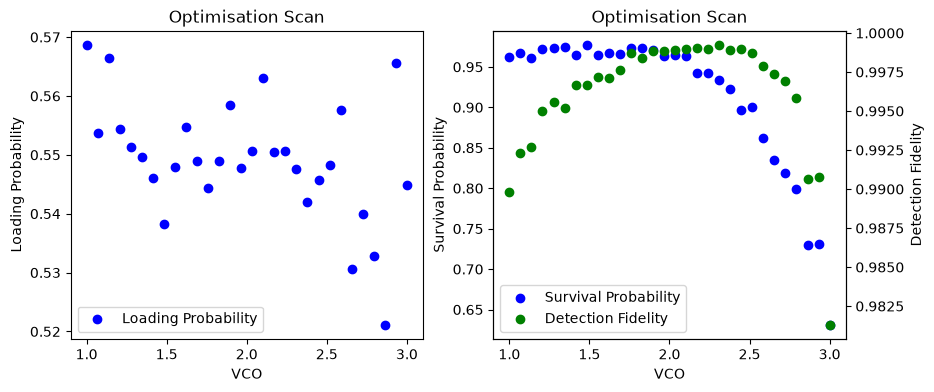

In [147]:
# Plot the loading probability vs vco in one plot and in a second plot plot the survival probability and detection fidelity vs vco in the same plot with different y axes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.scatter(vco_list, loading_list, label="Loading Probability", color="blue")
ax1.set_xlabel("VCO")
ax1.set_ylabel("Loading Probability")
ax1.set_title("Optimisation Scan")
ax1.legend()

# Create a second y-axis for the right plot
ax2_right = ax2.twinx()
ax2.scatter(vco_list, surv_list, label="Survival Probability", color="blue")
ax2_right.scatter(vco_list, fidelity_list, label="Detection Fidelity", color="green")

# Set labels and titles
ax2.set_xlabel("VCO")
ax2.set_ylabel("Survival Probability")
ax2_right.set_ylabel("Detection Fidelity")
ax2.set_title("Optimisation Scan")

# Combine legends
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_right.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2)

max_index = np.argmax(surv_list)

print(f"Optimal Cooling VCO: {vco_list[max_index]:.3f} V, Survival Probability: {surv_list[max_index]*100:.4f} %, Loading Probability: {loading_list[max_index]*100:.4f} %, Detection Fidelity: {fidelity_list[max_index]*100:.4f} %")

In [148]:
ExpParams.set_parameter("tImgCoolVCO", 1.6)

Parameter 'tImgCoolVCO' set to 1.6.


## Rearrangement Exp 1

In [46]:
import asyncio
from pytweezer.coordinators.rearrangement import Rearrangement
import time

coordinator = Rearrangement({"camera": hamcam, "slm": slm, "phasemask_generator": PM}, {})

data1 = np.stack(terms1[:4])
data2 = np.stack(terms2[:4])
await asyncio.to_thread(
    coordinator.initialise,
    terms1, terms2,
    d0=0.5, fps=1/(1e-6), threshold=an.convert_photons_to_counts(threshold_1)*1.1,
    grid_positions=grid_positions, profile="linear", window_size=5, feature_size=10, 
    detector=scorer, num_images=1
)

Occupancy via PSF detector (window 9, threshold 19.8).
Rearrangement node initialised.


In [47]:
# Experiment and camera setup
n_iterations = 1
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)

{'ok': True,
 'command': 'interface_method',
 'method': 'set_run_until_stopped',
 'state': 'accepted'}

In [48]:
N_iterations = 100  # adjust before running
imgs_software = []
err_indices = []
timings_log = []

for it in range(N_iterations):
    print(f"Running experiment iteration {it+1} / {N_iterations}")
    rearrangement_task = asyncio.create_task(asyncio.to_thread(coordinator.arm_rearrangement))

    time.sleep(0.1)
    exp.start_motmaster_experiment({
                "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
                "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"), 
                "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
                "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"), 
                "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
                "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"), 
                "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
                "tMolassesShimXccValue": ExpParams.get_parameter("tMolassesShimXccValue"), "tMolassesShimYccValue": ExpParams.get_parameter("tMolassesShimYccValue"), "tMolassesShimZccValue": ExpParams.get_parameter("tMolassesShimZccValue"),
                "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
                "BackgroundDrop": 0, "tTweezerSetVVA0": 8.0, "tTweezerSetVVA1": 10.0, "tDelay2": 5000})
    img0, imgs1, timings = await rearrangement_task
    print("Images acquired from rearrangement node.")

    if imgs1.sum() == 0:
        print(f"Empty image received at iteration {it+1}. Discarding...")
        err_indices.append(it)
    else:
        imgs_software.append([img0, *imgs1])
        timings_log.append(timings)

mean_rearrangement_time_ms = np.mean([t['total_rearrangement_ms'] for t in timings_log])
mean_calc_upload_time_ms = np.mean([t['calculation_and_upload_ms'] for t in timings_log])
mean_nframes = np.mean([t['n_frames'] for t in timings_log])
mean_speed = mean_rearrangement_time_ms / mean_nframes
mean_calc_upload_speed = mean_calc_upload_time_ms / mean_nframes
print(f"Average total rearrangement time = {mean_rearrangement_time_ms:.2f} ms")
print(f"Average number of frames = {mean_nframes:.2f}")
print(f"Average total speed = {mean_speed:.2f} ms/frame")
print(f"Average calculation and upload speed = {mean_calc_upload_speed:.2f} ms/frame")

Running experiment iteration 1 / 100
Rearrangement complete: 23 frames, 20.2394ms total (occupancy 0.1680ms, calculation+upload 20.0714ms).
Images acquired from rearrangement node.
Running experiment iteration 2 / 100
Rearrangement complete: 23 frames, 19.7819ms total (occupancy 0.1325ms, calculation+upload 19.6494ms).
Images acquired from rearrangement node.
Running experiment iteration 3 / 100
Rearrangement complete: 32 frames, 25.9909ms total (occupancy 0.1301ms, calculation+upload 25.8608ms).
Images acquired from rearrangement node.
Running experiment iteration 4 / 100
Rearrangement complete: 29 frames, 24.1209ms total (occupancy 0.1305ms, calculation+upload 23.9904ms).
Images acquired from rearrangement node.
Running experiment iteration 5 / 100
Rearrangement complete: 29 frames, 23.9166ms total (occupancy 0.1300ms, calculation+upload 23.7866ms).
Images acquired from rearrangement node.
Running experiment iteration 6 / 100
Rearrangement complete: 23 frames, 19.6076ms total (occupa

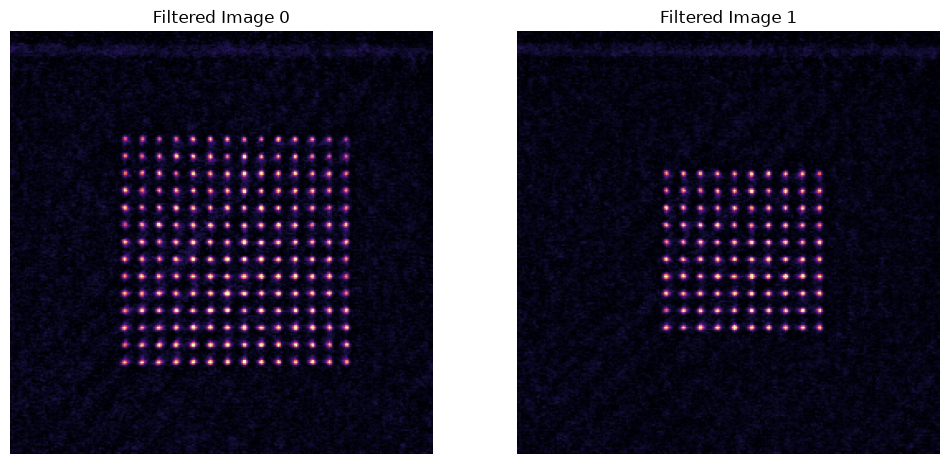

In [49]:
num_imgs_per_it = 2
tot_imgs = np.array(imgs_software)

plt.figure(figsize=(6*num_imgs_per_it, 6))
for n in range(num_imgs_per_it):
    imgs_n = tot_imgs[:, n, :, :]
    imgs__n_mean = imgs_n.mean(axis=0)
    imgs_n_mean_filtered = an.morphological_tophat_high_pass(imgs__n_mean, feature_size=feature_size)

    plt.subplot(1, num_imgs_per_it, n + 1)
    plt.imshow(imgs_n_mean_filtered, cmap='magma', vmax=0.6*imgs_n_mean_filtered.max())
    plt.title(f'Filtered Image {n}')
    plt.axis('off')
    
plt.show()

Trap (0) Loading Probability : 51.00 %
Trap (1) Loading Probability : 49.00 %
Trap (2) Loading Probability : 51.00 %
Trap (3) Loading Probability : 54.00 %
Trap (4) Loading Probability : 62.00 %
Trap (5) Loading Probability : 54.00 %
Trap (6) Loading Probability : 52.00 %
Trap (7) Loading Probability : 46.00 %
Trap (8) Loading Probability : 64.00 %
Trap (9) Loading Probability : 61.00 %
Trap (10) Loading Probability : 60.00 %
Trap (11) Loading Probability : 59.00 %
Trap (12) Loading Probability : 66.00 %
Trap (13) Loading Probability : 51.00 %
Trap (14) Loading Probability : 63.00 %
Trap (15) Loading Probability : 50.00 %
Trap (16) Loading Probability : 54.00 %
Trap (17) Loading Probability : 61.00 %
Trap (18) Loading Probability : 59.00 %
Trap (19) Loading Probability : 61.00 %
Trap (20) Loading Probability : 51.00 %
Trap (21) Loading Probability : 63.00 %
Trap (22) Loading Probability : 50.00 %
Trap (23) Loading Probability : 51.00 %
Trap (24) Loading Probability : 67.00 %
Trap (25) 

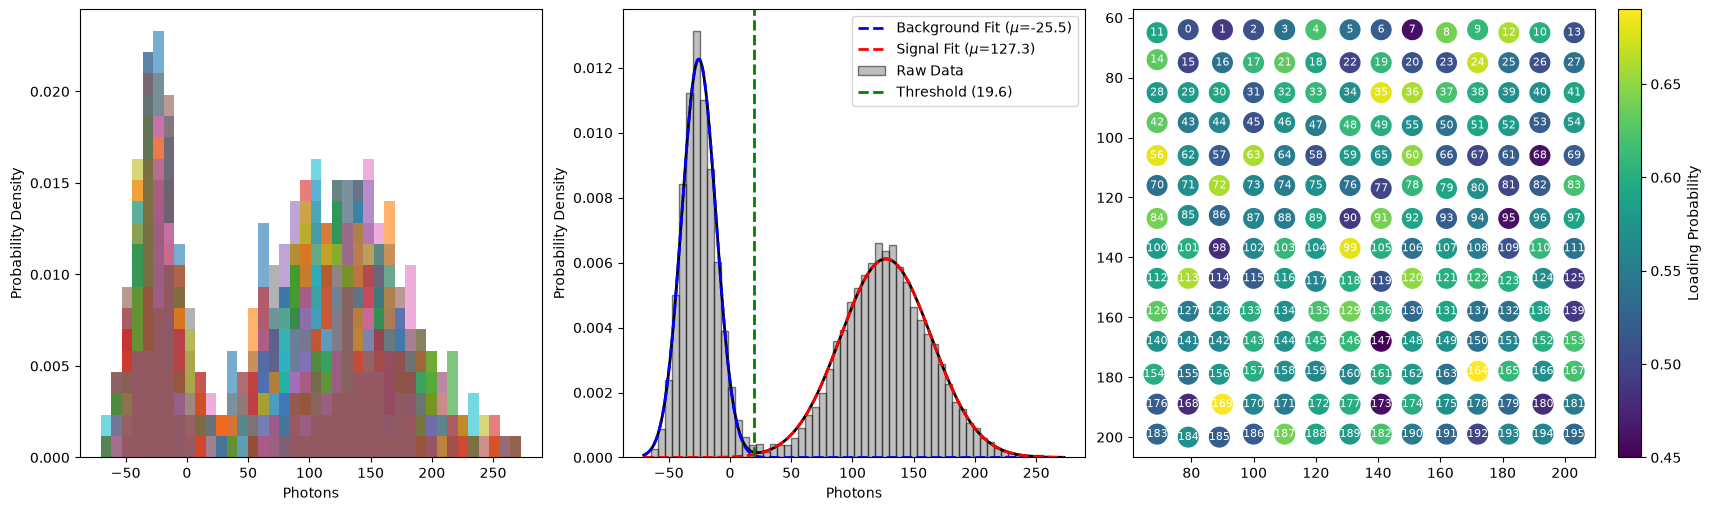

In [50]:
n = 0
imgs_n = tot_imgs[:, n, :, :]
imgs_n_filtered = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs_n]
photons, loading_probabilities, threshold, fidelity = an.get_array_loading_statistics(imgs_n_filtered, grid_positions, threshold=25, window_size=5, binning=60, 
                                                                                        show_histogram=True, scorer=scorer, threshold_detection=True, verbose=True, show_site_labels=True)

Looking for trap sites...
100 Atoms Detected.
Trap (0) Loading Probability : 50.00 %
Trap (1) Loading Probability : 63.00 %
Trap (2) Loading Probability : 57.00 %
Trap (3) Loading Probability : 58.00 %
Trap (4) Loading Probability : 48.00 %
Trap (5) Loading Probability : 65.00 %
Trap (6) Loading Probability : 60.00 %
Trap (7) Loading Probability : 55.00 %
Trap (8) Loading Probability : 58.00 %
Trap (9) Loading Probability : 51.00 %
Trap (10) Loading Probability : 54.00 %
Trap (11) Loading Probability : 66.00 %
Trap (12) Loading Probability : 54.00 %
Trap (13) Loading Probability : 54.00 %
Trap (14) Loading Probability : 59.00 %
Trap (15) Loading Probability : 60.00 %
Trap (16) Loading Probability : 61.00 %
Trap (17) Loading Probability : 53.00 %
Trap (18) Loading Probability : 57.00 %
Trap (19) Loading Probability : 54.00 %
Trap (20) Loading Probability : 64.00 %
Trap (21) Loading Probability : 63.00 %
Trap (22) Loading Probability : 60.00 %
Trap (23) Loading Probability : 59.00 %
Trap

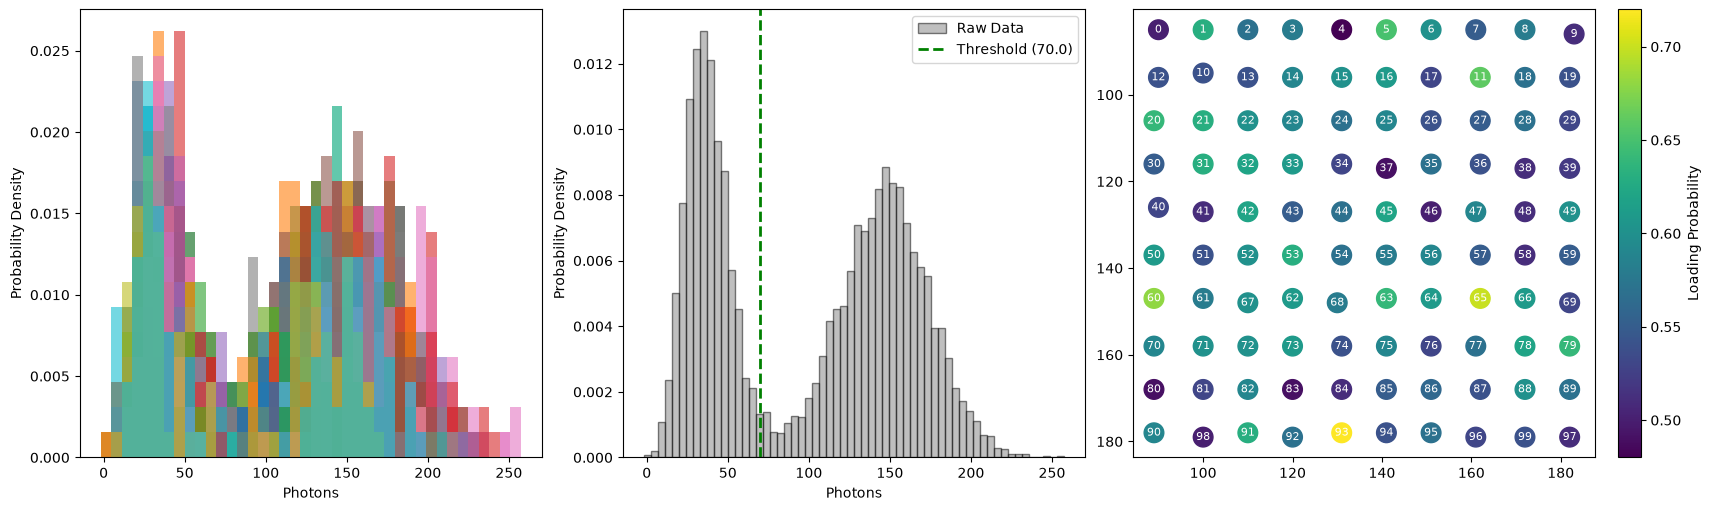

In [51]:
n = 1
imgs_n = tot_imgs[:, n, :, :]
imgs_n_mean = imgs_n.mean(axis=0)
imgs_n_mean_filtered = an.morphological_tophat_high_pass(imgs_n_mean, feature_size=feature_size)

feature_size, window = 10, 5
grid_positions_2, _ = an.detect_trap_sites(imgs_n_mean_filtered, 10*10, detection_step=100)

imgs_n_filtered = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs_n]
photons, loading_probabilities, threshold, fidelity = an.get_array_loading_statistics(imgs_n_filtered, grid_positions_2, threshold=70, window_size=5, binning=60, 
                                                                                        show_histogram=True, threshold_detection=False, verbose=True, show_site_labels=True)